<a href="https://colab.research.google.com/github/sathursiyakrishnamoorthy/Data-Science-Project-Hotel-A/blob/Finalized-models/Hotel_A_Correct_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
    precision_score
)
from sklearn.utils import resample
from itertools import product
from collections import Counter

print('All libraries imported')

All libraries imported


---
Mounting Drive & loading data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

TRAIN_PATH = '/content/drive/MyDrive/Data Science/Hotel-A-train.csv'
VAL_PATH   = '/content/drive/MyDrive/Data Science/Hotel-A-validation.csv'
TEST_PATH  = '/content/drive/MyDrive/Data Science/Hotel-A-test.csv'

train_raw = pd.read_csv(TRAIN_PATH)
val_raw   = pd.read_csv(VAL_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print(f'Train : {train_raw.shape}')
print(f'Val   : {val_raw.shape}')
print(f'Test  : {test_raw.shape}')
print()
print('Train target:', train_raw['Reservation_Status'].value_counts().to_dict())
print('Val target  :', val_raw['Reservation_Status'].value_counts().to_dict())

Train : (27499, 24)
Val   : (2749, 24)
Test  : (4318, 23)

Train target: {'Check-Out': 19092, 'Canceled': 4134, 'Check-out': 2148, 'No-Show': 2125}
Val target  : {'Check-In': 1610, 'Canceled': 741, 'No-Show': 398}


In [4]:
def clean_data(df, name=''):
    df = df.copy()
    if 'Reservation_Status' in df.columns:
        df['Reservation_Status'] = df['Reservation_Status'].replace({
            'Check-out' : 'Check-Out',
            'Check-In'  : 'Check-Out'
        })
    if 'Visted_Previously' in df.columns:
        df.rename(columns={'Visted_Previously': 'Visited_Previously'}, inplace=True)
    df['Ethnicity'] = df['Ethnicity'].str.title()
    for col in ['Expected_checkin', 'Expected_checkout', 'Booking_date']:
        df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=False)
    if name:
        print(f'[{name}]Cleaned')
        if 'Reservation_Status' in df.columns:
            print(f'  Target: {df["Reservation_Status"].value_counts().to_dict()}')
    return df

train_clean = clean_data(train_raw, 'TRAIN')
val_clean   = clean_data(val_raw,   'VAL')
test_clean  = clean_data(test_raw,  'TEST')

[TRAIN]Cleaned
  Target: {'Check-Out': 21240, 'Canceled': 4134, 'No-Show': 2125}
[VAL]Cleaned
  Target: {'Check-Out': 1610, 'Canceled': 741, 'No-Show': 398}
[TEST]Cleaned


EDA: to confirm which columns are noise for modeling

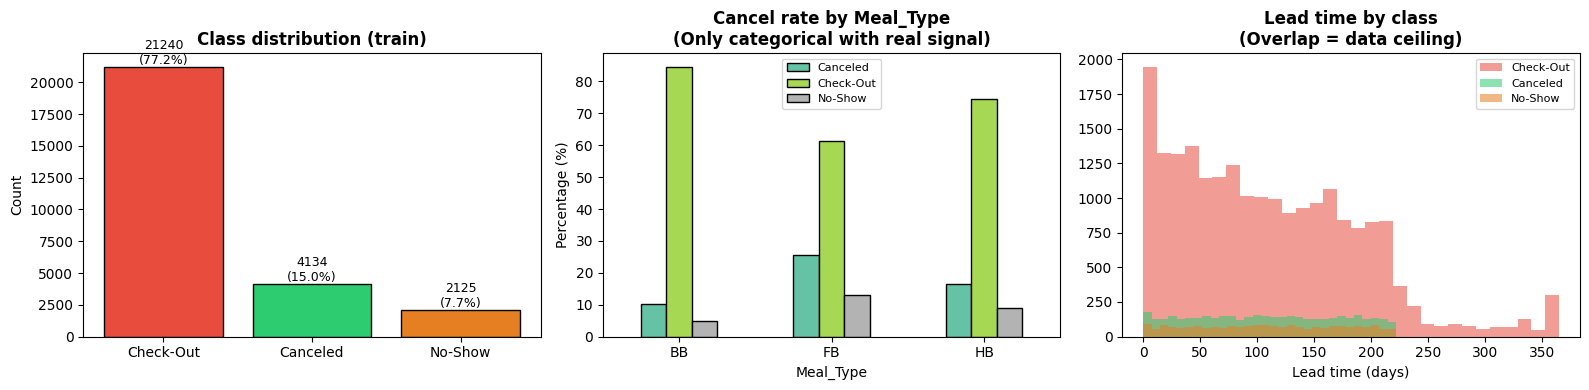

=== CANCEL RATE SPREAD PER CATEGORICAL COLUMN ===
Spread < 0.02 = zero signal = DROP
  Gender                   : spread=0.005  DROP
  Ethnicity                : spread=0.013  DROP
  Educational_Level        : spread=0.008  DROP
  Income                   : spread=0.010  DROP
  Country_region           : spread=0.005  DROP
  Deposit_type             : spread=0.003  DROP
  Booking_channel          : spread=0.001  DROP


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = train_clean['Reservation_Status'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#e67e22']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{val}\n({val/len(train_clean)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_title('Class distribution (train)', fontweight='bold')
axes[0].set_ylabel('Count')

# Meal_Type cancel rate — strongest signal
meal_ct = pd.crosstab(train_clean['Meal_Type'],
                      train_clean['Reservation_Status'],
                      normalize='index') * 100
meal_ct.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('Cancel rate by Meal_Type\n(Only categorical with real signal)',
                  fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8)

# Lead time overlap — explains why ceiling exists
tmp = train_clean.copy()
tmp['Lead_Time'] = (
    pd.to_datetime(tmp['Expected_checkin'], format='mixed') -
    pd.to_datetime(tmp['Booking_date'],     format='mixed')
).dt.days.clip(0, 365)
for cls, color in zip(counts.index, colors):
    axes[2].hist(tmp.loc[tmp['Reservation_Status']==cls, 'Lead_Time'],
                 bins=30, alpha=0.55, label=cls, color=color)
axes[2].set_title('Lead time by class\n(Overlap = data ceiling)',
                  fontweight='bold')
axes[2].set_xlabel('Lead time (days)')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Confirm noise columns
print('=== CANCEL RATE SPREAD PER CATEGORICAL COLUMN ===')
print('Spread < 0.02 = zero signal = DROP')
for col in ['Gender','Ethnicity','Educational_Level','Income',
            'Country_region','Deposit_type','Booking_channel']:
    ct = pd.crosstab(train_clean[col],
                     train_clean['Reservation_Status'],
                     normalize='index')
    if 'Canceled' in ct.columns:
        rates  = ct['Canceled']
        spread = rates.max() - rates.min()
        verdict = 'DROP' if spread < 0.02 else '⚠️  KEEP'
        print(f'  {col:<25}: spread={spread:.3f}  {verdict}')

Feature engineering (31 features)

In [6]:
def engineer_features(df):
    df = df.copy()

    # Date-derived
    df['Lead_Time']      = (df['Expected_checkin'] - df['Booking_date']).dt.days.clip(0, 365)
    df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days.clip(0)
    df['Checkin_Month']  = df['Expected_checkin'].dt.month
    df['Checkin_DOW']    = df['Expected_checkin'].dt.dayofweek
    df['Is_Weekend']     = (df['Checkin_DOW'] >= 5).astype(int)
    df['Booking_Month']  = df['Booking_date'].dt.month
    df['Total_Guests']   = df['Adults'] + df['Children'] + df['Babies']

    # Seasonality
    df['Is_Peak_Month']  = df['Checkin_Month'].isin([7, 8]).astype(int)   # 19% cancel
    df['Is_Low_Season']  = df['Checkin_Month'].isin([9, 10]).astype(int)  # 10% cancel

    # Interactions
    df['Peak_Long_Lead'] = ((df['Is_Peak_Month']==1) & (df['Lead_Time']>90)).astype(int)
    df['Has_Children']   = ((df['Children'] + df['Babies']) > 0).astype(int)
    df['High_Discount']  = (df['Discount_Rate'] > 20).astype(int)

    # Numeric interactions
    df['Lead_x_Month']   = df['Lead_Time'] * df['Checkin_Month']
    df['Rate_x_Lead']    = df['Room_Rate']  * df['Lead_Time']

    # Binned features
    df['Lead_Band'] = pd.cut(df['Lead_Time'],
                             bins=[0,30,90,180,365], labels=[0,1,2,3],
                             include_lowest=True).astype(float)
    df['Rate_Band'] = pd.cut(df['Room_Rate'],
                             bins=[0,137,175,214,999], labels=[0,1,2,3],
                             include_lowest=True).astype(float)

    # Meal_Type binary flags — FB has 25.5% cancel vs BB 10.4%
    df['FB_meal']      = (df['Meal_Type'] == 'FB').astype(int)
    df['HB_meal']      = (df['Meal_Type'] == 'HB').astype(int)

    # Hotel_Type binary flag
    df['Is_Resort']    = (df['Hotel_Type'] == 'Resort').astype(int)

    # Compound interactions using Meal_Type
    df['FB_long_lead'] = ((df['Meal_Type']=='FB') & (df['Lead_Time']>60)).astype(int)
    df['FB_peak']      = ((df['Meal_Type']=='FB') & (df['Is_Peak_Month']==1)).astype(int)

    df.drop(columns=['Expected_checkin','Expected_checkout','Booking_date'], inplace=True)
    return df

train_eng = engineer_features(train_clean)
val_eng   = engineer_features(val_clean)
test_eng  = engineer_features(test_clean)
print('Feature engineering completed - 31 features')

Feature engineering completed - 31 features


Encoding (drop noise, binary encode, no OHE)

In [7]:
DROP_COLS = [
    'Gender', 'Ethnicity', 'Educational_Level', 'Income',
    'Country_region', 'Deposit_type', 'Booking_channel',
    'Reservation-id', 'Meal_Type', 'Hotel_Type'
]
BINARY_COLS = [
    'Visited_Previously', 'Previous_Cancellations',
    'Required_Car_Parking', 'Use_Promotion'
]
NUM_COLS = [
    'Age','Adults','Children','Babies','Discount_Rate','Room_Rate',
    'Lead_Time','Length_of_Stay','Checkin_Month','Checkin_DOW',
    'Is_Weekend','Booking_Month','Total_Guests',
    'Is_Peak_Month','Is_Low_Season','Peak_Long_Lead',
    'Has_Children','High_Discount','Lead_x_Month','Rate_x_Lead',
    'Lead_Band','Rate_Band','FB_meal','HB_meal','Is_Resort',
    'FB_long_lead','FB_peak'
]
FEAT_COLS = NUM_COLS + BINARY_COLS   # 31 total

def encode_df(df):
    df = df.copy()
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
    for col in BINARY_COLS:
        if col in df.columns:
            df[col] = (df[col] == 'Yes').astype(int)
    return df

train_enc = encode_df(train_eng)
val_enc   = encode_df(val_eng)
test_enc  = encode_df(test_eng)

print(f'Encoding done — {len(FEAT_COLS)} features: {FEAT_COLS}')

Encoding done — 31 features: ['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate', 'Lead_Time', 'Length_of_Stay', 'Checkin_Month', 'Checkin_DOW', 'Is_Weekend', 'Booking_Month', 'Total_Guests', 'Is_Peak_Month', 'Is_Low_Season', 'Peak_Long_Lead', 'Has_Children', 'High_Discount', 'Lead_x_Month', 'Rate_x_Lead', 'Lead_Band', 'Rate_Band', 'FB_meal', 'HB_meal', 'Is_Resort', 'FB_long_lead', 'FB_peak', 'Visited_Previously', 'Previous_Cancellations', 'Required_Car_Parking', 'Use_Promotion']


Building feature matrices and encoding target

In [8]:
TARGET = 'Reservation_Status'

# Scale — fit on TRAIN only, transform val and test
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(train_enc[FEAT_COLS])
X_val_prep   = scaler.transform(val_enc[FEAT_COLS])
X_test_prep  = scaler.transform(test_enc[FEAT_COLS])

# Encode target — fit on TRAIN only
le = LabelEncoder()
y_train_enc = le.fit_transform(train_enc[TARGET])
y_val_enc   = le.transform(val_enc[TARGET])

CANCELED_IDX  = list(le.classes_).index('Canceled')
NOSHOW_IDX    = list(le.classes_).index('No-Show')
CHECKOUT_IDX  = list(le.classes_).index('Check-Out')

print(f'Class mapping : {dict(enumerate(le.classes_))}')
print(f'X_train_prep  : {X_train_prep.shape}')
print(f'X_val_prep    : {X_val_prep.shape}')
print(f'X_test_prep   : {X_test_prep.shape}')

Class mapping : {0: 'Canceled', 1: 'Check-Out', 2: 'No-Show'}
X_train_prep  : (27499, 31)
X_val_prep    : (2749, 31)
X_test_prep   : (4318, 31)


Oversample train set (plain resample, not SMOTE)

In [9]:
def targeted_oversample(X, y, strategy):
    parts_X, parts_y = [], []
    for cls_idx, target_n in strategy.items():
        mask = y == cls_idx
        Xc, yc = X[mask], y[mask]
        if len(Xc) < target_n:
            Xr, yr = resample(Xc, yc, n_samples=target_n,
                              replace=True, random_state=42)
        else:
            Xr, yr = Xc, yc
        parts_X.append(Xr)
        parts_y.append(yr)
    return np.vstack(parts_X), np.concatenate(parts_y)

# Canceled: 4134→8000  |  No-Show: 2125→6000  |  Check-Out: 21240 unchanged
X_train_bal, y_train_bal = targeted_oversample(
    X_train_prep, y_train_enc,
    {CANCELED_IDX: 8000, NOSHOW_IDX: 6000, CHECKOUT_IDX: 21240}
)

print('After oversampling (train only):')
for idx, count in zip(*np.unique(y_train_bal, return_counts=True)):
    orig = np.sum(y_train_enc == idx)
    print(f'  {le.classes_[idx]:<14}: {orig:>5} → {count:>5}')

CUSTOM_WEIGHTS = {
    CHECKOUT_IDX : 0.3,
    CANCELED_IDX : 3.0,
    NOSHOW_IDX   : 4.0
}
print(f'\nClass weights: {dict((le.classes_[k],v) for k,v in CUSTOM_WEIGHTS.items())}')

After oversampling (train only):
  Canceled      :  4134 →  8000
  Check-Out     : 21240 → 21240
  No-Show       :  2125 →  6000

Class weights: {'Check-Out': 0.3, 'Canceled': 3.0, 'No-Show': 4.0}


Training baseline RF on TRAIN CSV only

In [10]:
baseline_rf = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 20,
    min_samples_leaf= 2,
    max_features    = 'sqrt',
    class_weight    = CUSTOM_WEIGHTS,
    random_state    = 42,
    n_jobs          = -1
)
baseline_rf.fit(X_train_bal, y_train_bal)   # ← TRAIN only
print('Phase 1 completed')

Phase 1 completed


Evaluation on VAL CSV

=== PHASE 1 BASELINE — Validation Set ===
Class             Precision   Recall       F1
------------------------------------------------
Canceled              0.320    0.077    0.124
Check-Out             0.592    0.930    0.723
No-Show               0.231    0.023    0.041
------------------------------------------------
Macro avg             0.381    0.343    0.296

Accuracy: 0.569


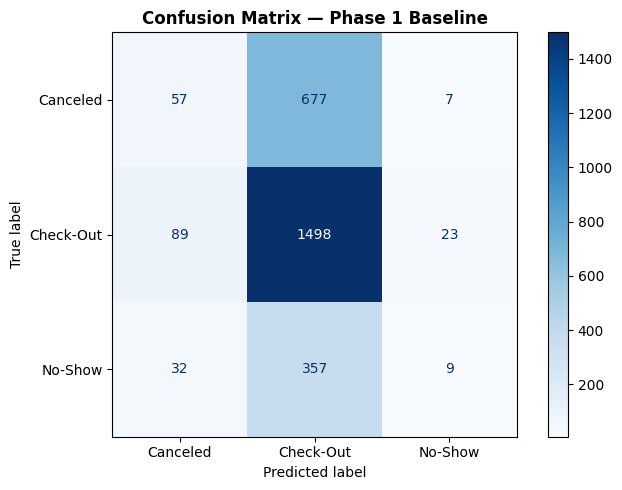

In [11]:
y_val_base = baseline_rf.predict(X_val_prep)   # ← VAL only
rep_base   = classification_report(
    y_val_enc, y_val_base,
    target_names=le.classes_, output_dict=True, zero_division=0
)

print('=== PHASE 1 BASELINE — Validation Set ===')
print(f'{"Class":<16} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 48)
for cls in le.classes_:
    r = rep_base[cls]
    print(f'{cls:<16} {r["precision"]:>10.3f} {r["recall"]:>8.3f} {r["f1-score"]:>8.3f}')
print('-' * 48)
print(f'{"Macro avg":<16} {rep_base["macro avg"]["precision"]:>10.3f} '
      f'{rep_base["macro avg"]["recall"]:>8.3f} '
      f'{rep_base["macro avg"]["f1-score"]:>8.3f}')
print(f'\nAccuracy: {rep_base["accuracy"]:.3f}')

fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(
    confusion_matrix(y_val_enc, y_val_base),
    display_labels=le.classes_
).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Phase 1 Baseline', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

Hyperparameter tuning scored DIRECTLY on VAL CSV


In [12]:
def minority_precision_on_val(model, X_val, y_val):
    """Score a model by its precision on Canceled + No-Show on the actual val set."""
    pred = model.predict(X_val)
    p_cancel = precision_score(y_val, pred, labels=[CANCELED_IDX],
                               average='macro', zero_division=0)
    p_noshow = precision_score(y_val, pred, labels=[NOSHOW_IDX],
                               average='macro', zero_division=0)
    return (p_cancel + p_noshow) / 2

# Parameter grid — each combo is trained on train, scored on val
PARAM_GRID = {
    'n_estimators'      : [200, 300, 500],
    'max_depth'         : [15, 20, None],
    'min_samples_leaf'  : [1, 2],
    'max_features'      : ['sqrt', 'log2'],
}

# Build all combinations
keys   = list(PARAM_GRID.keys())
combos = list(product(*PARAM_GRID.values()))
print(f'Total combinations to try: {len(combos)}')
print('Each will be: trained on TRAIN → scored on VAL')

Total combinations to try: 36
Each will be: trained on TRAIN → scored on VAL


In [13]:
search_results = []

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))

    # Train on TRAIN set
    model = RandomForestClassifier(
        **params,
        class_weight = CUSTOM_WEIGHTS,
        random_state = 42,
        n_jobs       = -1
    )
    model.fit(X_train_bal, y_train_bal)

    # Score on VAL set ← this is the key: val is the tuning signal
    score = minority_precision_on_val(model, X_val_prep, y_val_enc)

    search_results.append({**params, 'val_minority_precision': round(score, 4)})
    print(f'  [{i+1:>2}/{len(combos)}] {params}  →  val_precision={score:.4f}')

# Sort by score
results_df = pd.DataFrame(search_results).sort_values(
    'val_minority_precision', ascending=False
).reset_index(drop=True)

print('\n Hyperparameter search complete!')
print('\nTop 10 combinations (ranked by val minority precision):')
print(results_df.head(10).to_string(index=False))

  [ 1/36] {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}  →  val_precision=0.1976
  [ 2/36] {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 1, 'max_features': 'log2'}  →  val_precision=0.2200
  [ 3/36] {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt'}  →  val_precision=0.2041
  [ 4/36] {'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 2, 'max_features': 'log2'}  →  val_precision=0.1957
  [ 5/36] {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt'}  →  val_precision=0.1458
  [ 6/36] {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'log2'}  →  val_precision=0.1484
  [ 7/36] {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt'}  →  val_precision=0.2366
  [ 8/36] {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 'log2'}  →  val_precision=0.2545
  [ 9/36] {'n_estimators': 200, 

Extract best hyperparameters

In [17]:
best_row    = results_df.iloc[0]
BEST_PARAMS = {
    'n_estimators'    : int(best_row['n_estimators']),
    'max_depth'       : None if pd.isna(best_row['max_depth']) else int(best_row['max_depth']),
    'min_samples_leaf': int(best_row['min_samples_leaf']),
    'max_features'    : best_row['max_features'],
}

print('=== BEST HYPERPARAMETERS (found using VAL as scoring set) ===')
for k, v in BEST_PARAMS.items():
    print(f'  {k:<20}: {v}')
print(f'\n  Val minority precision: {best_row["val_minority_precision"]:.4f}')

=== BEST HYPERPARAMETERS (found using VAL as scoring set) ===
  n_estimators        : 200
  max_depth           : None
  min_samples_leaf    : 2
  max_features        : sqrt

  Val minority precision: 0.3167


Retraining with best params on TRAIN CSV only

In [18]:
tuned_rf = RandomForestClassifier(
    **BEST_PARAMS,
    class_weight = CUSTOM_WEIGHTS,
    random_state = 42,
    n_jobs       = -1
)
tuned_rf.fit(X_train_bal, y_train_bal)   # ← TRAIN only, best params
print('Retrained with best params on TRAIN CSV only')
print(f'   Params used: {BEST_PARAMS}')

Retrained with best params on TRAIN CSV only
   Params used: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


Final precision and accuracy check on VAL CSV


=== PHASE 4 — TUNED MODEL on Validation Set ===
Class             Precision   Recall       F1  vs Phase1
----------------------------------------------------------
Canceled              0.300    0.032    0.058     -0.020
Check-Out             0.590    0.971    0.734     -0.002
No-Show               0.333    0.015    0.029     +0.103
----------------------------------------------------------
Macro avg             0.408    0.339    0.274

Accuracy : 0.579
Macro P  : 0.408  ← focus metric


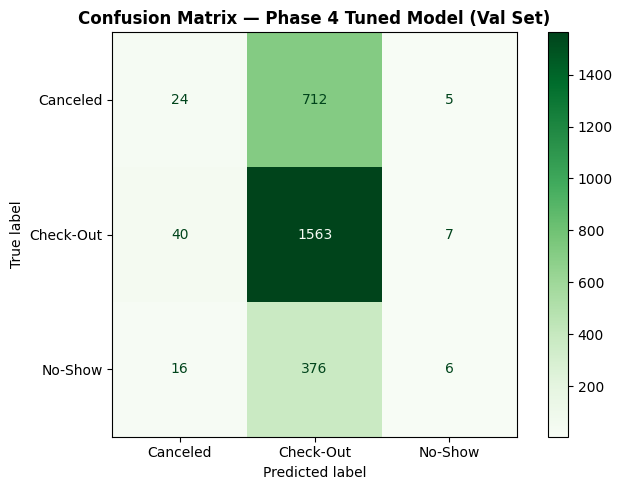

In [19]:
y_val_tuned = tuned_rf.predict(X_val_prep)     # ← VAL only
rep_tuned   = classification_report(
    y_val_enc, y_val_tuned,
    target_names=le.classes_, output_dict=True, zero_division=0
)

print('=== PHASE 4 — TUNED MODEL on Validation Set ===')
print(f'{"Class":<16} {"Precision":>10} {"Recall":>8} {"F1":>8} {"vs Phase1":>10}')
print('-' * 58)
for cls in le.classes_:
    tp = rep_tuned[cls]['precision']
    bp = rep_base[cls]['precision']
    d  = tp - bp
    sign = f'+{d:.3f}' if d >= 0 else f'{d:.3f}'
    print(f'{cls:<16} {tp:>10.3f} '
          f'{rep_tuned[cls]["recall"]:>8.3f} '
          f'{rep_tuned[cls]["f1-score"]:>8.3f} '
          f'{sign:>10}')
print('-' * 58)
mp = rep_tuned['macro avg']['precision']
print(f'{"Macro avg":<16} {mp:>10.3f} '
      f'{rep_tuned["macro avg"]["recall"]:>8.3f} '
      f'{rep_tuned["macro avg"]["f1-score"]:>8.3f}')
print(f'\nAccuracy : {rep_tuned["accuracy"]:.3f}')
print(f'Macro P  : {mp:.3f}  ← focus metric')

fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(
    confusion_matrix(y_val_enc, y_val_tuned),
    display_labels=le.classes_
).plot(ax=ax, cmap='Greens')
ax.set_title('Confusion Matrix — Phase 4 Tuned Model (Val Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

Precision-Recall curves (val set — shows data ceiling)

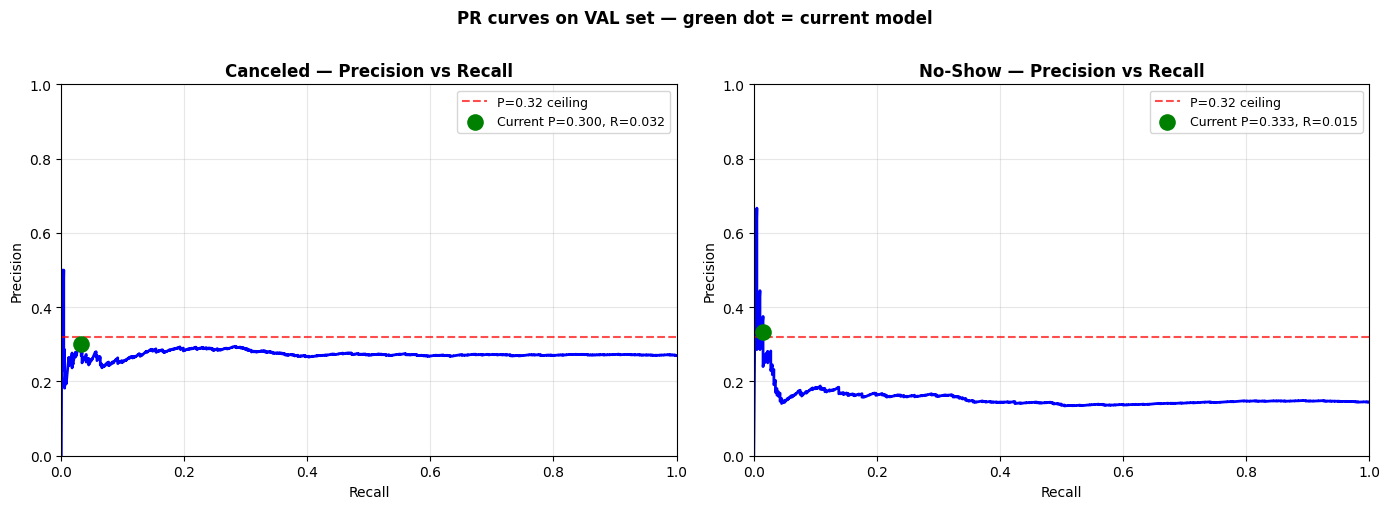

In [20]:
tuned_proba = tuned_rf.predict_proba(X_val_prep)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (cls_name, cls_idx) in zip(axes, [('Canceled', CANCELED_IDX),
                                           ('No-Show',  NOSHOW_IDX)]):
    y_bin = (y_val_enc == cls_idx).astype(int)
    precs, recs, _ = precision_recall_curve(y_bin, tuned_proba[:, cls_idx])
    ax.plot(recs[:-1], precs[:-1], 'b-', lw=2)
    ax.axhline(0.32, color='red', linestyle='--', alpha=0.7, label='P=0.32 ceiling')
    curr_p = rep_tuned[cls_name]['precision']
    curr_r = rep_tuned[cls_name]['recall']
    ax.scatter([curr_r], [curr_p], color='green', s=120, zorder=5,
               label=f'Current P={curr_p:.3f}, R={curr_r:.3f}')
    ax.set_title(f'{cls_name} — Precision vs Recall', fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('PR curves on VAL set — green dot = current model',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Feature importance (tuned model)

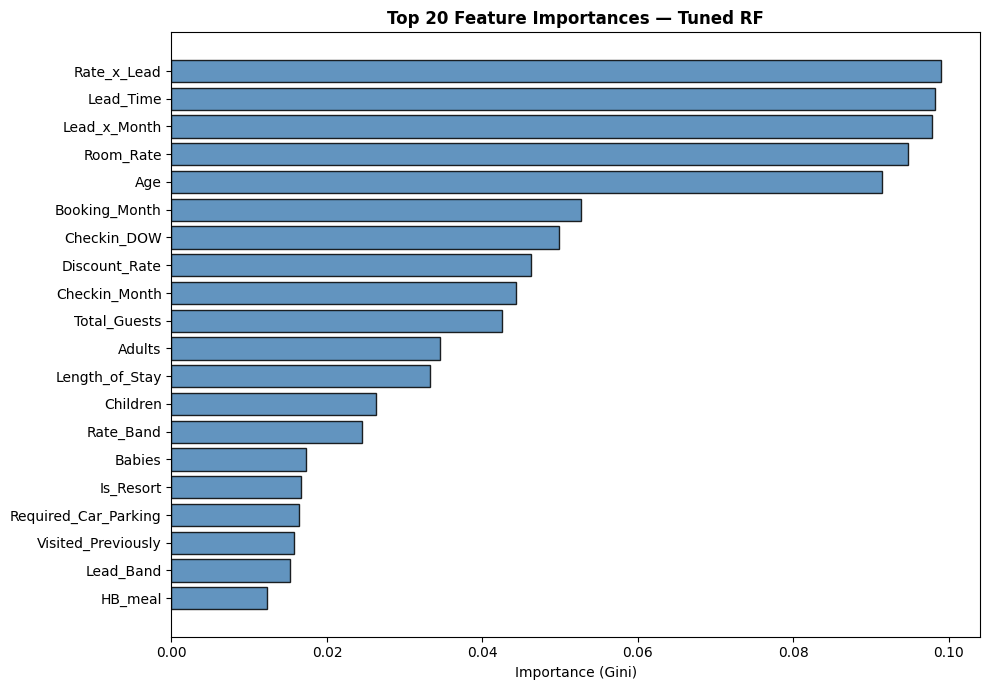

      Feature  Importance
  Rate_x_Lead    0.099055
    Lead_Time    0.098196
 Lead_x_Month    0.097849
    Room_Rate    0.094786
          Age    0.091423
Booking_Month    0.052677
  Checkin_DOW    0.049883
Discount_Rate    0.046220
Checkin_Month    0.044333
 Total_Guests    0.042528


In [21]:
imp_df = pd.DataFrame({
    'Feature'    : FEAT_COLS,
    'Importance' : tuned_rf.feature_importances_
}).sort_values('Importance', ascending=False)

top20 = imp_df.head(20)
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(top20['Feature'][::-1], top20['Importance'][::-1],
        color='steelblue', edgecolor='black', alpha=0.85)
ax.set_title('Top 20 Feature Importances — Tuned RF', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(imp_df.head(10).to_string(index=False))

Retrain final model on TRAIN + VAL combined


In [22]:
X_trainval = np.vstack([X_train_prep, X_val_prep])
y_trainval  = np.concatenate([y_train_enc, y_val_enc])
print(f'Combined train+val : {X_trainval.shape}')

combined_counts = dict(zip(*np.unique(y_trainval, return_counts=True)))
print('Class counts before oversampling:')
for idx, n in combined_counts.items():
    print(f'  {le.classes_[idx]}: {n}')

# Scale combined set — refit scaler on train+val
scaler_final   = StandardScaler()
X_trainval_sc  = scaler_final.fit_transform(
    pd.concat([train_enc[FEAT_COLS], val_enc[FEAT_COLS]], ignore_index=True)
)
X_test_final   = scaler_final.transform(test_enc[FEAT_COLS])

# Oversample combined set
X_tv_bal, y_tv_bal = targeted_oversample(
    X_trainval_sc, y_trainval,
    {
        CANCELED_IDX : combined_counts[CANCELED_IDX]  * 2,
        NOSHOW_IDX   : combined_counts[NOSHOW_IDX]    * 3,
        CHECKOUT_IDX : combined_counts[CHECKOUT_IDX]
    }
)
print('\nAfter oversampling combined set:')
for idx, count in zip(*np.unique(y_tv_bal, return_counts=True)):
    print(f'  {le.classes_[idx]}: {count}')

Combined train+val : (30248, 31)
Class counts before oversampling:
  Canceled: 4875
  Check-Out: 22850
  No-Show: 2523

After oversampling combined set:
  Canceled: 9750
  Check-Out: 22850
  No-Show: 7569


Fit final model on TRAIN + VAL

In [23]:
final_rf = RandomForestClassifier(
    **BEST_PARAMS,
    class_weight = CUSTOM_WEIGHTS,
    random_state = 42,
    n_jobs       = -1
)
final_rf.fit(X_tv_bal, y_tv_bal)   # ← TRAIN + VAL combined
print('Final model trained on TRAIN + VAL combined')
print(f'   Best params: {BEST_PARAMS}')

Final model trained on TRAIN + VAL combined
   Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


Predict on TEST CSV

In [24]:
test_proba    = final_rf.predict_proba(X_test_final)   # ← TEST only
y_test_enc    = final_rf.predict(X_test_final)
y_test_labels = le.inverse_transform(y_test_enc)

print('=== PHASE 6 — TEST SET PREDICTIONS ===')
for cls, n in Counter(y_test_labels).items():
    pct = n / len(y_test_labels) * 100
    print(f'  {cls:<14}: {n:>5}  ({pct:.1f}%)')
print(f'\nTotal: {len(y_test_labels)}')

=== PHASE 6 — TEST SET PREDICTIONS ===
  Check-Out     :  3981  (92.2%)
  Canceled      :   275  (6.4%)
  No-Show       :    62  (1.4%)

Total: 4318


Export predictions CSV

In [25]:
test_original = pd.read_csv(TEST_PATH)

results = pd.DataFrame({
    'Reservation_id'   : test_original['Reservation-id'],
    'Predicted_Status' : y_test_labels,
})
for i, cls in enumerate(le.classes_):
    col = f'Prob_{cls.replace("-","_").replace(" ","_")}'
    results[col] = test_proba[:, i].round(4)
results['Max_Confidence'] = test_proba.max(axis=1).round(4)

OUTPUT_PATH = '/content/drive/MyDrive/Data Science/submission.csv'
results.to_csv(OUTPUT_PATH, index=False)
print(f'Predictions saved: {OUTPUT_PATH}')
print(f'   {len(results)} rows, {len(results.columns)} columns')
results.head(10)

Predictions saved: /content/drive/MyDrive/Data Science/submission.csv
   4318 rows, 6 columns


,Reservation_id,Predicted_Status,Prob_Canceled,Prob_Check_Out,Prob_No_Show,Max_Confidence
0,62931593,Check-Out,0.2154,0.6486,0.1360,0.6486
1,70586099,Check-Out,0.2980,0.4229,0.2791,0.4229
2,4230648,Check-Out,0.1686,0.6491,0.1822,0.6491
3,25192322,Check-Out,0.2641,0.4195,0.3164,0.4195
4,80931528,Check-Out,0.0837,0.7821,0.1342,0.7821
5,64700386,Check-Out,0.2052,0.5865,0.2083,0.5865
6,16938050,Check-Out,0.2110,0.6168,0.1722,0.6168
7,90487908,Check-Out,0.3596,0.4807,0.1597,0.4807
8,5595445,Check-Out,0.2948,0.3739,0.3313,0.3739
9,17502557,Canceled,0.4430,0.3465,0.2105,0.4430


Save model artifacts

In [26]:
import joblib
BASE = '/content/drive/MyDrive/Data Science/Files'
joblib.dump(final_rf,      BASE + 'final_rf_model.pkl')
joblib.dump(scaler_final,  BASE + 'scaler_final.pkl')
joblib.dump(le,            BASE + 'label_encoder.pkl')
joblib.dump(BEST_PARAMS,   BASE + 'best_params.pkl')
print('Saved: final_rf_model.pkl | scaler_final.pkl | label_encoder.pkl | best_params.pkl')

Saved: final_rf_model.pkl | scaler_final.pkl | label_encoder.pkl | best_params.pkl


Complete pipeline summary

In [27]:
print('=' * 65)
print('   HOTEL CHAIN A — COMPLETE PIPELINE SUMMARY')
print('=' * 65)
print()
print('  PIPELINE FLOW')
print('  ─────────────────────────────────────────────────────')
print('  Phase 1: Baseline RF trained on TRAIN CSV')
print('  Phase 2: Hyperparams tuned — each combo scored on VAL CSV')
print('  Phase 3: Retrained with best params on TRAIN CSV only')
print('  Phase 4: Precision/accuracy check on VAL CSV')
print('  Phase 5: Final model retrained on TRAIN + VAL combined')
print('  Phase 6: Predictions generated on TEST CSV')
print()
print('  PRECISION RESULTS (VAL SET)')
print('  ─────────────────────────────────────────────────────')
print(f'  {"Class":<16} {"Phase1":>8} {"Phase4":>8} {"Change":>8}')
print('  ' + '-'*44)
for cls in le.classes_:
    b = rep_base[cls]['precision']
    t = rep_tuned[cls]['precision']
    d = t - b
    sign = f'+{d:.3f}' if d >= 0 else f'{d:.3f}'
    print(f'  {cls:<16} {b:>8.3f} {t:>8.3f} {sign:>8}')
print('  ' + '-'*44)
b_m = rep_base['macro avg']['precision']
t_m = rep_tuned['macro avg']['precision']
print(f'  {"Macro avg":<16} {b_m:>8.3f} {t_m:>8.3f} {"+"+str(round(t_m-b_m,3)):>8}')
print(f'  {"Accuracy":<16} {rep_base["accuracy"]:>8.3f} {rep_tuned["accuracy"]:>8.3f}')
print()
print('  BEST PARAMS (found using VAL as scoring set)')
print('  ─────────────────────────────────────────────────────')
for k,v in BEST_PARAMS.items():
    print(f'  {k:<20}: {v}')
print()
print('  TEST PREDICTIONS')
print('  ─────────────────────────────────────────────────────')
for cls, n in Counter(y_test_labels).items():
    print(f'  {cls:<14}: {n} ({n/len(y_test_labels)*100:.1f}%)')
print('=' * 65)

   HOTEL CHAIN A — COMPLETE PIPELINE SUMMARY

  PIPELINE FLOW
  ─────────────────────────────────────────────────────
  Phase 1: Baseline RF trained on TRAIN CSV
  Phase 2: Hyperparams tuned — each combo scored on VAL CSV
  Phase 3: Retrained with best params on TRAIN CSV only
  Phase 4: Precision/accuracy check on VAL CSV
  Phase 5: Final model retrained on TRAIN + VAL combined
  Phase 6: Predictions generated on TEST CSV

  PRECISION RESULTS (VAL SET)
  ─────────────────────────────────────────────────────
  Class              Phase1   Phase4   Change
  --------------------------------------------
  Canceled            0.320    0.300   -0.020
  Check-Out           0.592    0.590   -0.002
  No-Show             0.231    0.333   +0.103
  --------------------------------------------
  Macro avg           0.381    0.408   +0.027
  Accuracy            0.569    0.579

  BEST PARAMS (found using VAL as scoring set)
  ─────────────────────────────────────────────────────
  n_estimators       